In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os
os.chdir('/home/pgcp-ai/MachineLearning/Datasets')

In [3]:
df = pd.read_csv('Boston.csv')
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [5]:
X,y = df.drop('medv',axis=1),df['medv']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=26)

In [9]:
ridge = Ridge()
lr = LinearRegression()
lr.fit(X_train,y_train)


LinearRegression()

In [11]:
ridge.fit(X_train,y_train)

Ridge()

In [12]:
y_pred_lin = lr.predict(X_test)
y_pred_ridge = ridge.predict(X_test)

In [25]:
import matplotlib.pyplot as plt


In [26]:
print(f"R2 Score Lin Reg: {r2_score(y_test,y_pred_lin)}")
print(f"R2 Score Ridge Reg: {r2_score(y_test,y_pred_ridge)}")

R2 Score Lin Reg: 0.7467569320916609
R2 Score Ridge Reg: 0.7443182494036571


In [47]:
alpha_values = [0.01, 0.1, 0.5, 1, 1.5, 2.5, 5, 10]
dict_alpha = dict()
for i in alpha_values:
    ridge = Ridge(alpha = i)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_test)
    dict_alpha[i] = r2_score(y_test, y_pred_ridge)
    print(f"R2 score with {i} alpha value is: {r2_score(y_test, y_pred_ridge)}")

R2 score with 0.01 alpha value is: 0.7467757608116165
R2 score with 0.1 alpha value is: 0.7468150816549348
R2 score with 0.5 alpha value is: 0.7458053608194992
R2 score with 1 alpha value is: 0.7443182494036571
R2 score with 1.5 alpha value is: 0.7432655207463665
R2 score with 2.5 alpha value is: 0.7421761128406063
R2 score with 5 alpha value is: 0.7419381578159241
R2 score with 10 alpha value is: 0.7435059743890553


In [48]:
df = pd.DataFrame(dict_alpha.items(),columns=['Alpha','R2 Score'])
df.sort_values(by = 'R2 Score', ascending = False)

,Alpha,R2 Score
1,0.10,0.746815
0,0.01,0.746776
2,0.50,0.745805
3,1.00,0.744318
7,10.00,0.743506
4,1.50,0.743266
5,2.50,0.742176
6,5.00,0.741938


In [54]:
import seaborn as sns

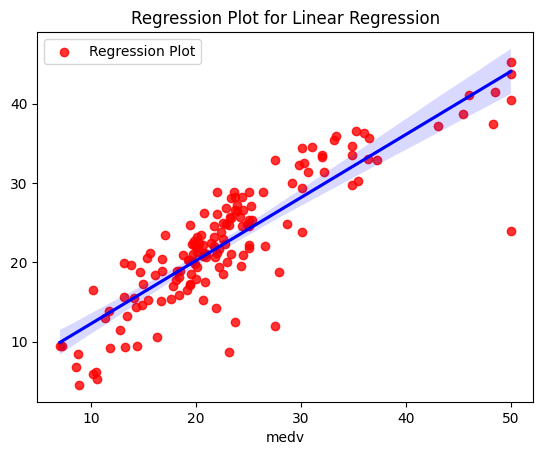

In [71]:
sns.regplot(x=y_test,y=y_pred_lin,marker='o',color='blue',scatter_kws = {'color' : 'red','label':'Y_test vs Y_Pred'},label='Regression Plot')
plt.title('Regression Plot for Linear Regression')
plt.legend()
plt.show()

<Axes: xlabel='medv'>

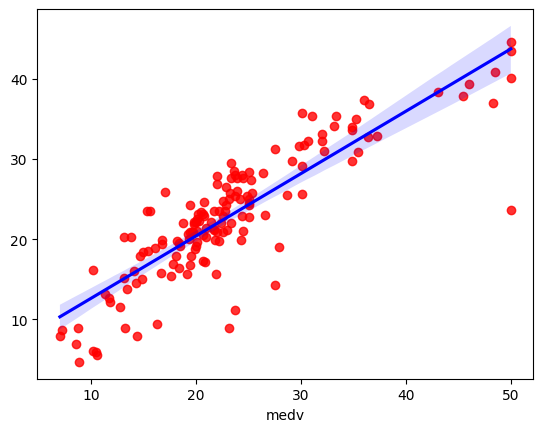

In [67]:
sns.regplot(x=y_test,y=y_pred_ridge,marker='o',color='blue',scatter_kws = {'color' : 'red'},)